In [49]:
# Программы для
# Кейс: Прогнозирование потребления электроэнергии городом
# Автор: студентка группы ЕТ-142 Ермакова Софья Юрьевна

# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import norm

# Загрузка используемого датасета с гугл диска
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/My Drive/Tetuan City power consumption.csv")

# Список каналов
channels = [
    'Temperature',
    'Humidity',
    'Wind Speed',
    'general diffuse flows',
    'diffuse flows',
    'Zone 1 Power Consumption',
    'Zone 2  Power Consumption',
    'Zone 3  Power Consumption'
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Вывод первых строк данных, получение общей информации и определение
# размерности данных

# 1. Первые 10 строк
print("Первые 10 строк данных:")
print(df.head(10))
print("\n")

# 2. Общая информация
print("Общая информация о данных:")
print(df.info())
print("\n")

# 3. Размерность данных
print("Размерность данных:")
print(f"Строк (наблюдений): {df.shape[0]}")
print(f"Столбцов (всего): {df.shape[1]}")
print(f"Формат: {df.shape[0]} x {df.shape[1]}")

Первые 10 строк данных:
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   
5  1/1/2017 0:50        5.853      76.9       0.081                  0.059   
6  1/1/2017 1:00        5.641      77.7       0.080                  0.048   
7  1/1/2017 1:10        5.496      78.2       0.085                  0.055   
8  1/1/2017 1:20        5.678      78.1       0.081                  0.066   
9  1/1/2017 1:30        5.491      77.3       0.082                  0.062   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620  

In [ ]:
# Преобразование в формат datetime и установите его в качестве индекса
df = pd.read_csv(path)

df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

print(df.head())
print(f"\nИндекс: {df.index.dtype}")
print(f"Пример: {df.index[0]}")

                     Temperature  Humidity  Wind Speed  general diffuse flows  \
DateTime                                                                        
2017-01-01 00:00:00        6.559      73.8       0.083                  0.051   
2017-01-01 00:10:00        6.414      74.5       0.083                  0.070   
2017-01-01 00:20:00        6.313      74.5       0.080                  0.062   
2017-01-01 00:30:00        6.121      75.0       0.083                  0.091   
2017-01-01 00:40:00        5.921      75.7       0.081                  0.048   

                     diffuse flows  Zone 1 Power Consumption  \
DateTime                                                       
2017-01-01 00:00:00          0.119               34055.69620   
2017-01-01 00:10:00          0.085               29814.68354   
2017-01-01 00:20:00          0.100               29128.10127   
2017-01-01 00:30:00          0.096               28228.86076   
2017-01-01 00:40:00          0.085              

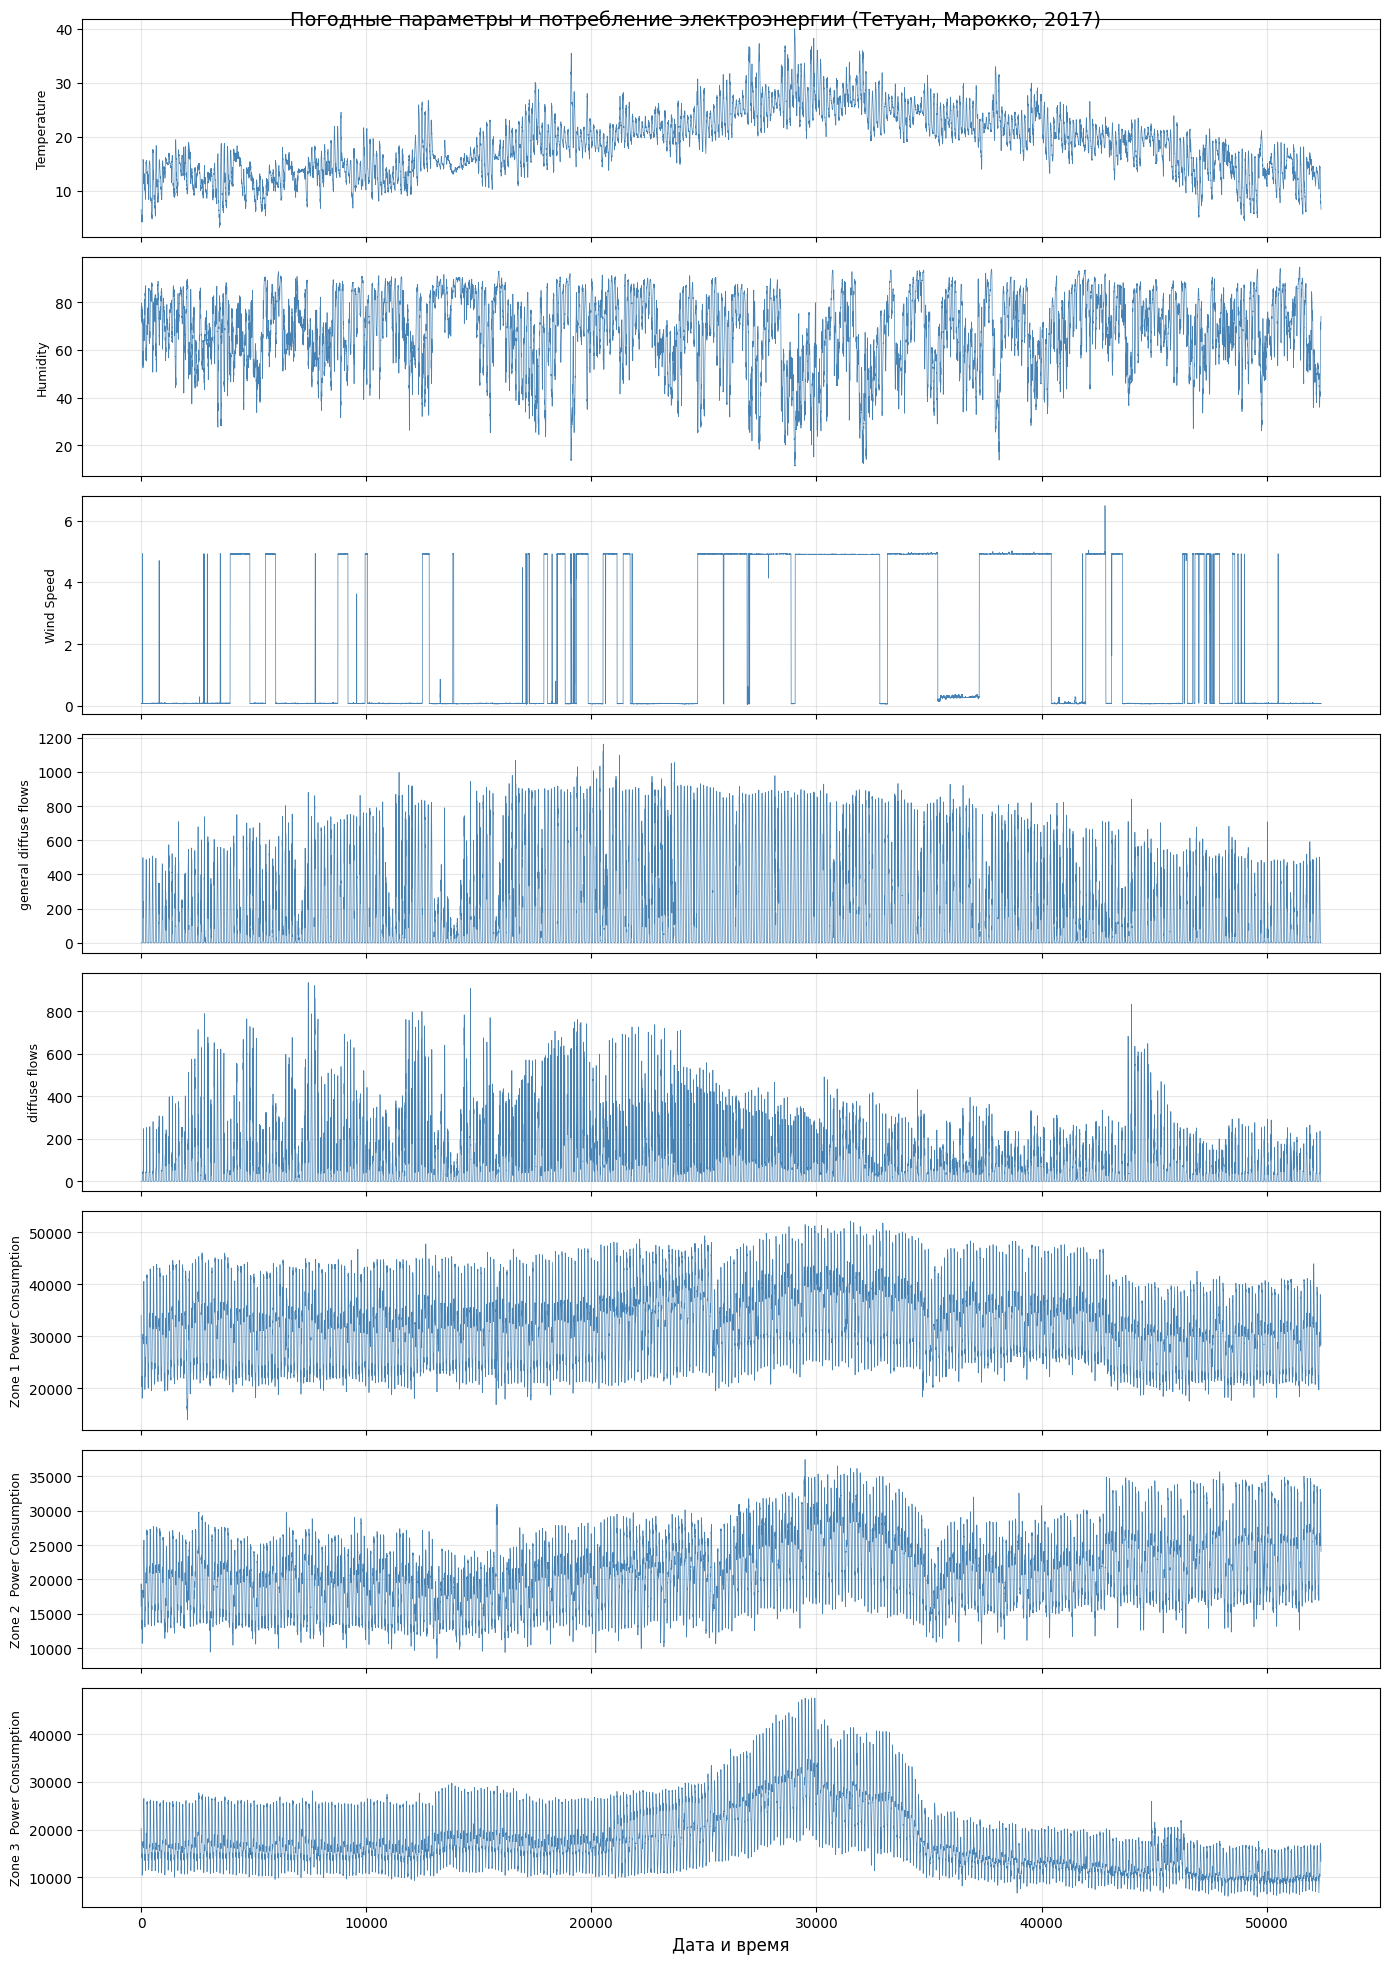

In [ ]:
# Визуализация графиков 8 каналов
fig, axes = plt.subplots(8, 1, figsize=(14, 20), sharex=True)

# Построение графиков
for i, channel in enumerate(channels):
    axes[i].plot(df.index, df[channel], linewidth=0.5, color='steelblue')
    axes[i].set_ylabel(channel, fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Настройка графиков
axes[-1].set_xlabel('Дата и время', fontsize=12)
fig.suptitle('Погодные параметры и потребление электроэнергии (Тетуан, Марокко, 2017)', fontsize=14)
plt.tight_layout()
plt.show()

Период: 0 - 143


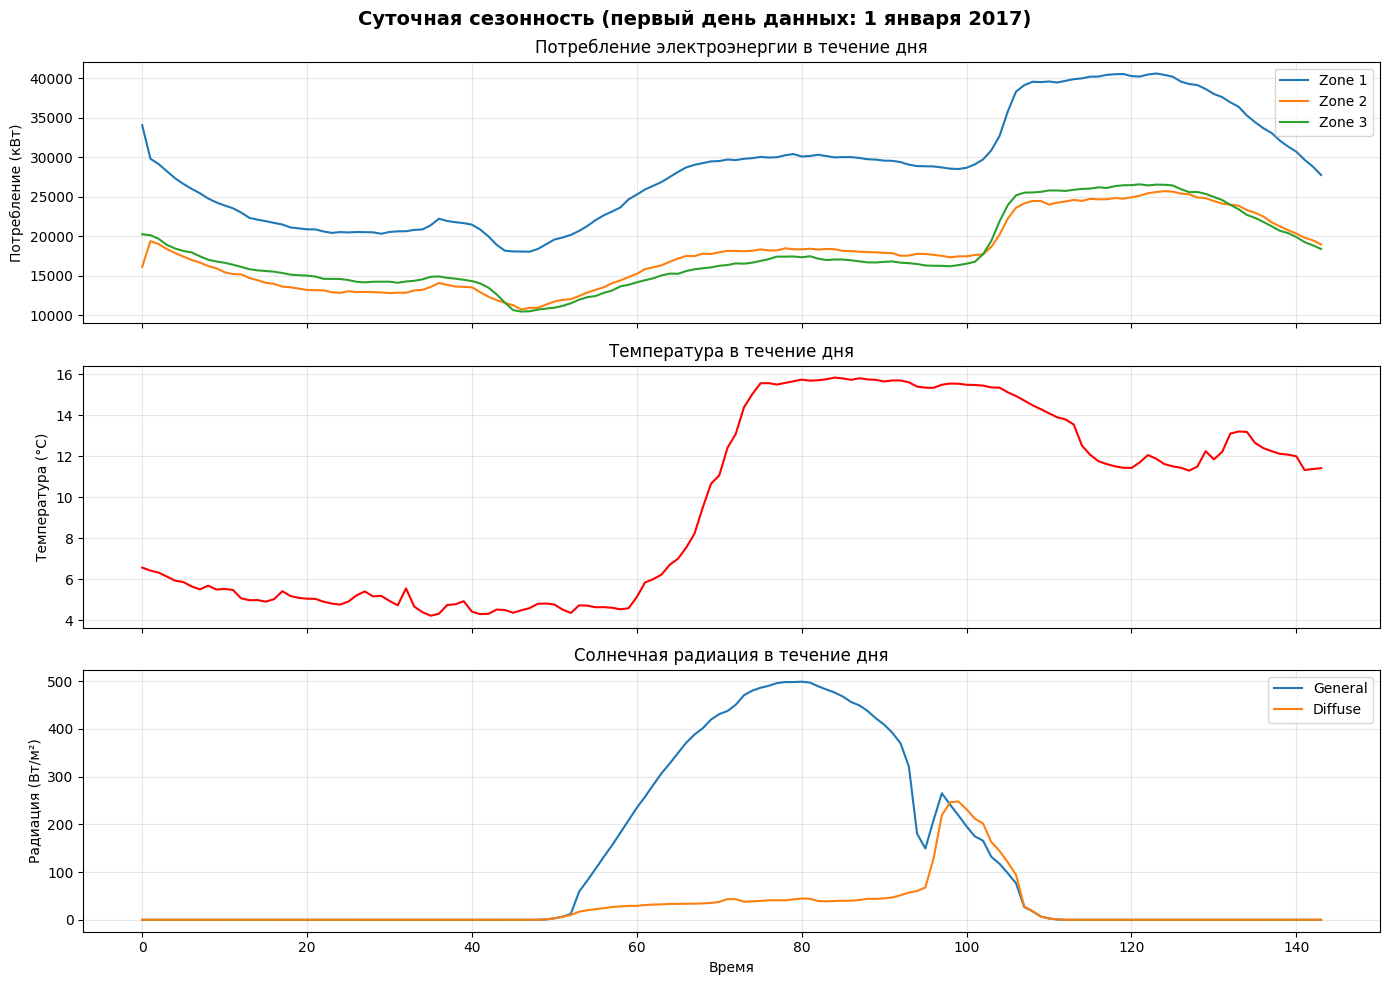

In [ ]:
# Построение графика суточной сезонности

# Берем первые 144 записи (1 день = 24 часа * 6 измерений в час = 144 записи по 10 минут)
day_data = df.iloc[:144]

print(f"Период: {day_data.index[0]} - {day_data.index[-1]}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Потребление
axes[0].plot(day_data.index, day_data['Zone 1 Power Consumption'], label='Zone 1', linewidth=1.5)
axes[0].plot(day_data.index, day_data['Zone 2  Power Consumption'], label='Zone 2', linewidth=1.5)
axes[0].plot(day_data.index, day_data['Zone 3  Power Consumption'], label='Zone 3', linewidth=1.5)
axes[0].set_ylabel('Потребление (кВт)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Потребление электроэнергии в течение дня', fontsize=12)

# Температура
axes[1].plot(day_data.index, day_data['Temperature'], color='red', linewidth=1.5)
axes[1].set_ylabel('Температура (°C)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Температура в течение дня', fontsize=12)

# Солнечная радиация
axes[2].plot(day_data.index, day_data['general diffuse flows'], label='General', linewidth=1.5)
axes[2].plot(day_data.index, day_data['diffuse flows'], label='Diffuse', linewidth=1.5)
axes[2].set_ylabel('Радиация (Вт/м²)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Солнечная радиация в течение дня', fontsize=12)

axes[-1].set_xlabel('Время')
fig.suptitle('Суточная сезонность (первый день данных: 1 января 2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Период: с 0 по 1007


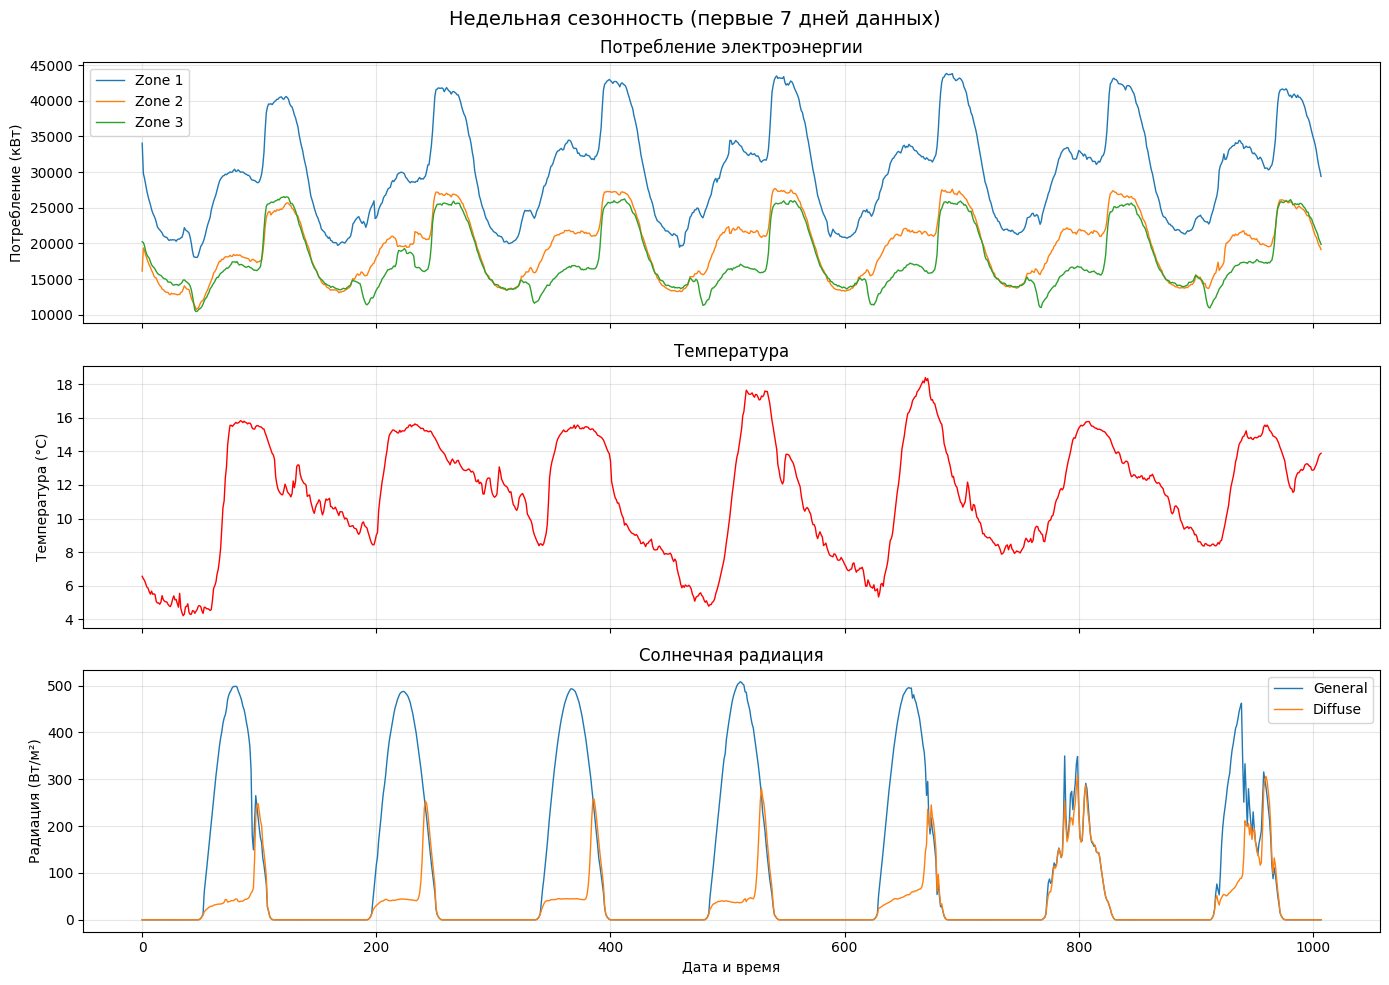

In [ ]:
# Построение графика недельной сезонности

# Берем первые 1008 записей (7 дней * 144 измерения * 10 минут)
week_data = df.iloc[:1008]

print(f"Период: с {week_data.index[0]} по {week_data.index[-1]}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Потребление
axes[0].plot(week_data.index, week_data['Zone 1 Power Consumption'], label='Zone 1', linewidth=1)
axes[0].plot(week_data.index, week_data['Zone 2  Power Consumption'], label='Zone 2', linewidth=1)
axes[0].plot(week_data.index, week_data['Zone 3  Power Consumption'], label='Zone 3', linewidth=1)
axes[0].set_ylabel('Потребление (кВт)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Потребление электроэнергии', fontsize=12)

# Температура
axes[1].plot(week_data.index, week_data['Temperature'], color='red', linewidth=1)
axes[1].set_ylabel('Температура (°C)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Температура', fontsize=12)

# Радиация
axes[2].plot(week_data.index, week_data['general diffuse flows'], label='General', linewidth=1)
axes[2].plot(week_data.index, week_data['diffuse flows'], label='Diffuse', linewidth=1)
axes[2].set_ylabel('Радиация (Вт/м²)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Солнечная радиация', fontsize=12)

axes[-1].set_xlabel('Дата и время')
fig.suptitle('Недельная сезонность (первые 7 дней данных)', fontsize=14)
plt.tight_layout()
plt.show()

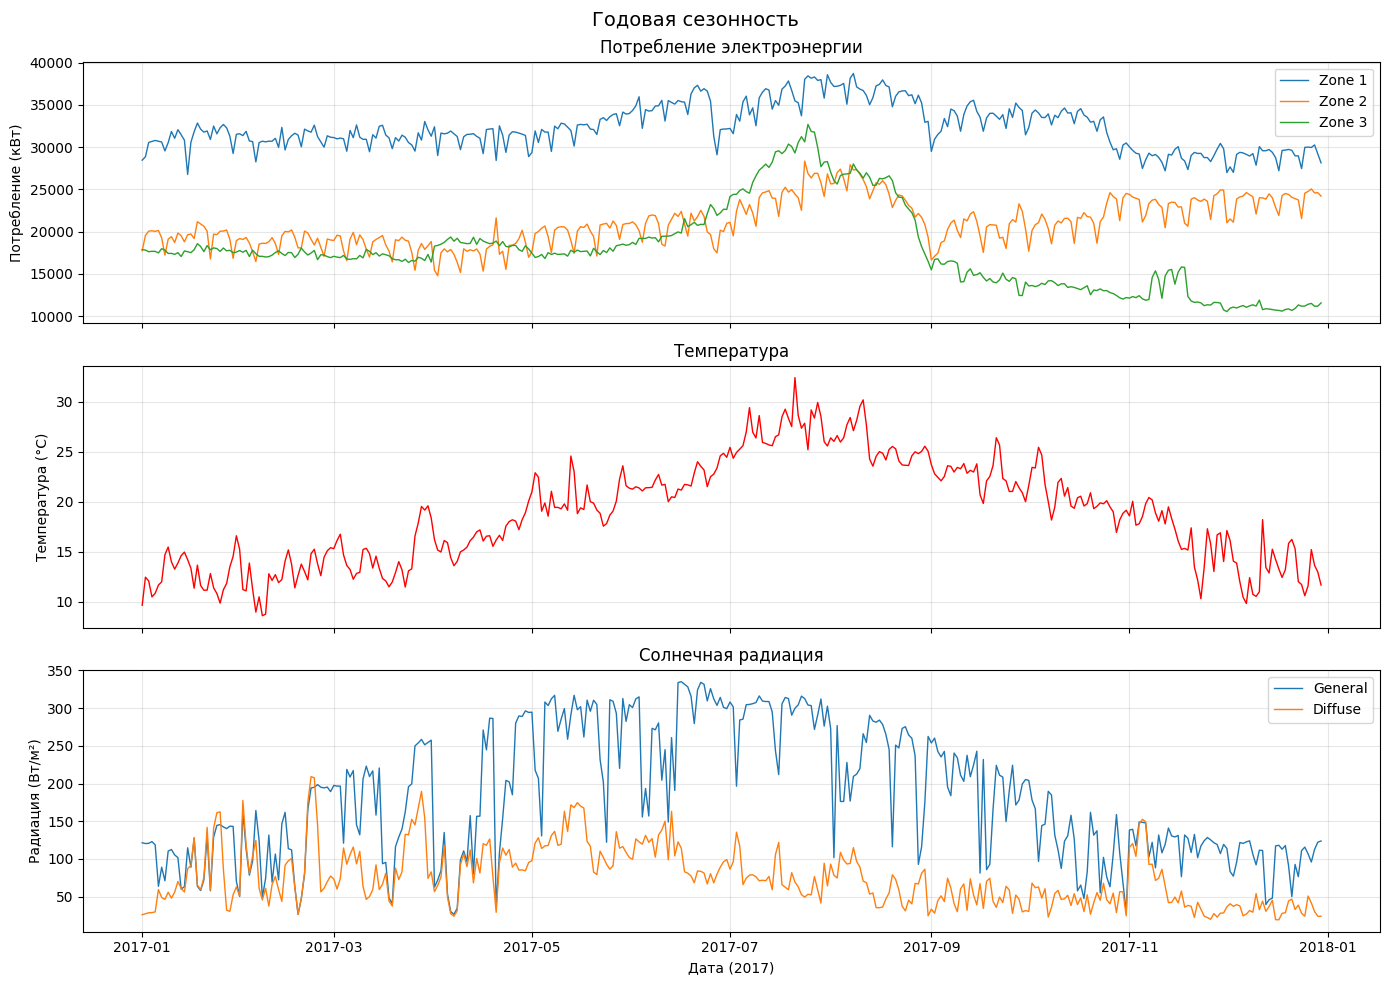

In [9]:
# Построение графика годовой сезонности

# Объединение по дням
year_data = df.resample('D').mean()

# График
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Потребление
axes[0].plot(year_data.index, year_data['Zone 1 Power Consumption'], label='Zone 1', linewidth=1)
axes[0].plot(year_data.index, year_data['Zone 2  Power Consumption'], label='Zone 2', linewidth=1)
axes[0].plot(year_data.index, year_data['Zone 3  Power Consumption'], label='Zone 3', linewidth=1)
axes[0].set_ylabel('Потребление (кВт)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Потребление электроэнергии')

# Температура
axes[1].plot(year_data.index, year_data['Temperature'], color='red', linewidth=1)
axes[1].set_ylabel('Температура (°C)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Температура')

# Радиация
axes[2].plot(year_data.index, year_data['general diffuse flows'], label='General', linewidth=1)
axes[2].plot(year_data.index, year_data['diffuse flows'], label='Diffuse', linewidth=1)
axes[2].set_ylabel('Радиация (Вт/м²)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Солнечная радиация')

axes[-1].set_xlabel('Дата (2017)')
fig.suptitle('Годовая сезонность', fontsize=14)
plt.tight_layout()
plt.show()

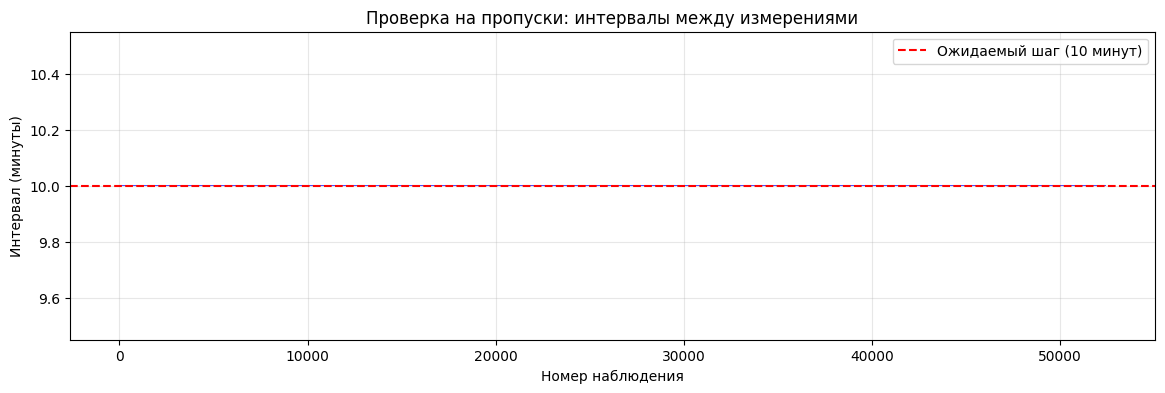

Уникальные интервалы: [10.]
Минимальный интервал: 10.00 минут
Максимальный интервал: 10.00 минут
Есть ли отклонения от 10 минут? False


In [18]:
# Проверка на пропуски: интервалы между измерениями
time_diff = np.diff(df.index.view('int64')) / 60e9  # в минутах (1e9 нс в секунду, *60 для минут)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_diff, linewidth=0.5, color='blue')
ax.axhline(y=10, color='red', linestyle='--', label='Ожидаемый шаг (10 минут)')
ax.set_ylabel('Интервал (минуты)', fontsize=10)
ax.set_xlabel('Номер наблюдения', fontsize=10)
ax.set_title('Проверка на пропуски: интервалы между измерениями', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Уникальные интервалы: {np.unique(time_diff)}")
print(f"Минимальный интервал: {time_diff.min():.2f} минут")
print(f"Максимальный интервал: {time_diff.max():.2f} минут")
print(f"Есть ли отклонения от 10 минут? {not np.allclose(time_diff, 10, atol=0.1)}")

In [41]:
# Нахождение статистических характеристик для каждого канала

# Создание DataFrame для статистики
stats = pd.DataFrame()

for channel in channels:
    stats.loc['count', channel] = df[channel].count()
    stats.loc['mean', channel] = df[channel].mean()
    stats.loc['std', channel] = df[channel].std()
    stats.loc['min', channel] = df[channel].min()
    stats.loc['Q1 (25%)', channel] = df[channel].quantile(0.25)
    stats.loc['Q2 (50%/median)', channel] = df[channel].quantile(0.50)
    stats.loc['Q3 (75%)', channel] = df[channel].quantile(0.75)
    stats.loc['max', channel] = df[channel].max()

# Транспонирование
stats = stats.T

# Форматируем вывод
pd.set_option('display.float_format', '{:.2f}'.format)
print("Статистические характеристики каналов")
print(stats)

Статистические характеристики каналов
                             count     mean     std      min  Q1 (25%)  \
Temperature               52416.00    18.81    5.82     3.25     14.41   
Humidity                  52416.00    68.26   15.55    11.34     58.31   
Wind Speed                52416.00     1.96    2.35     0.05      0.08   
general diffuse flows     52416.00   182.70  264.40     0.00      0.06   
diffuse flows             52416.00    75.03  124.21     0.01      0.12   
Zone 1 Power Consumption  52416.00 32344.97 7130.56 13895.70  26310.67   
Zone 2  Power Consumption 52416.00 21042.51 5201.47  8560.08  16980.77   
Zone 3  Power Consumption 52416.00 17835.41 6622.17  5935.17  13129.33   

                           Q2 (50%/median)  Q3 (75%)      max  
Temperature                          18.78     22.89    40.01  
Humidity                             69.86     81.40    94.80  
Wind Speed                            0.09      4.92     6.48  
general diffuse flows                 5

In [23]:
# Вычисление шага дискретизации

time_diff = df.index[1] - df.index[0]

print("Частота дискретизации")
print(f"Шаг между измерениями: {time_diff}")
print(f"В минутах: {time_diff.total_seconds() / 60:.0f} минут")
print(f"Частота: {60 / (time_diff.total_seconds() / 60):.1f} измерений в час")
print(f"Измерений в сутки: {24 * 60 / (time_diff.total_seconds() / 60):.0f}")

# Проверка равномерности
time_diffs = df.index.to_series().diff().dropna()
is_uniform = (time_diffs == time_diff).all()
print(f"\nИнтервалы равномерны: {'Да' if is_uniform else 'Нет'}")

Частота дискретизации
Шаг между измерениями: 0 days 00:10:00
В минутах: 10 минут
Частота: 6.0 измерений в час
Измерений в сутки: 144

Интервалы равномерны: Да


In [42]:
# Вычисление доли пропусков в каждом канале

print("Доля пропущенных значений")

for channel in channels:
    missing_count = df[channel].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    print(f"{channel:30} : {missing_count:6} пропусков ({missing_percent:.2f}%)")

total_missing = df.isnull().sum().sum()
print(f"\nВсего пропусков в данных: {total_missing}")

Доля пропущенных значений
Temperature                    :      0 пропусков (0.00%)
Humidity                       :      0 пропусков (0.00%)
Wind Speed                     :      0 пропусков (0.00%)
general diffuse flows          :      0 пропусков (0.00%)
diffuse flows                  :      0 пропусков (0.00%)
Zone 1 Power Consumption       :      0 пропусков (0.00%)
Zone 2  Power Consumption      :      0 пропусков (0.00%)
Zone 3  Power Consumption      :      0 пропусков (0.00%)

Всего пропусков в данных: 0


Выбросы по правилу 3 сигм
Temperature                    :    89 выбросов (0.17%)
   Диапазон: [1.36, 36.26]
Humidity                       :   209 выбросов (0.40%)
   Диапазон: [21.61, 114.91]
Wind Speed                     :     0 выбросов (0.00%)
   Диапазон: [-5.09, 9.01]
general diffuse flows          :    23 выбросов (0.04%)
   Диапазон: [-610.51, 975.90]
diffuse flows                  :  1361 выбросов (2.60%)
   Диапазон: [-297.60, 447.66]
Zone 1 Power Consumption       :     0 выбросов (0.00%)
   Диапазон: [10953.28, 53736.66]
Zone 2  Power Consumption      :     1 выбросов (0.00%)
   Диапазон: [5438.11, 36646.91]
Zone 3  Power Consumption      :   653 выбросов (1.25%)
   Диапазон: [-2031.09, 37701.90]


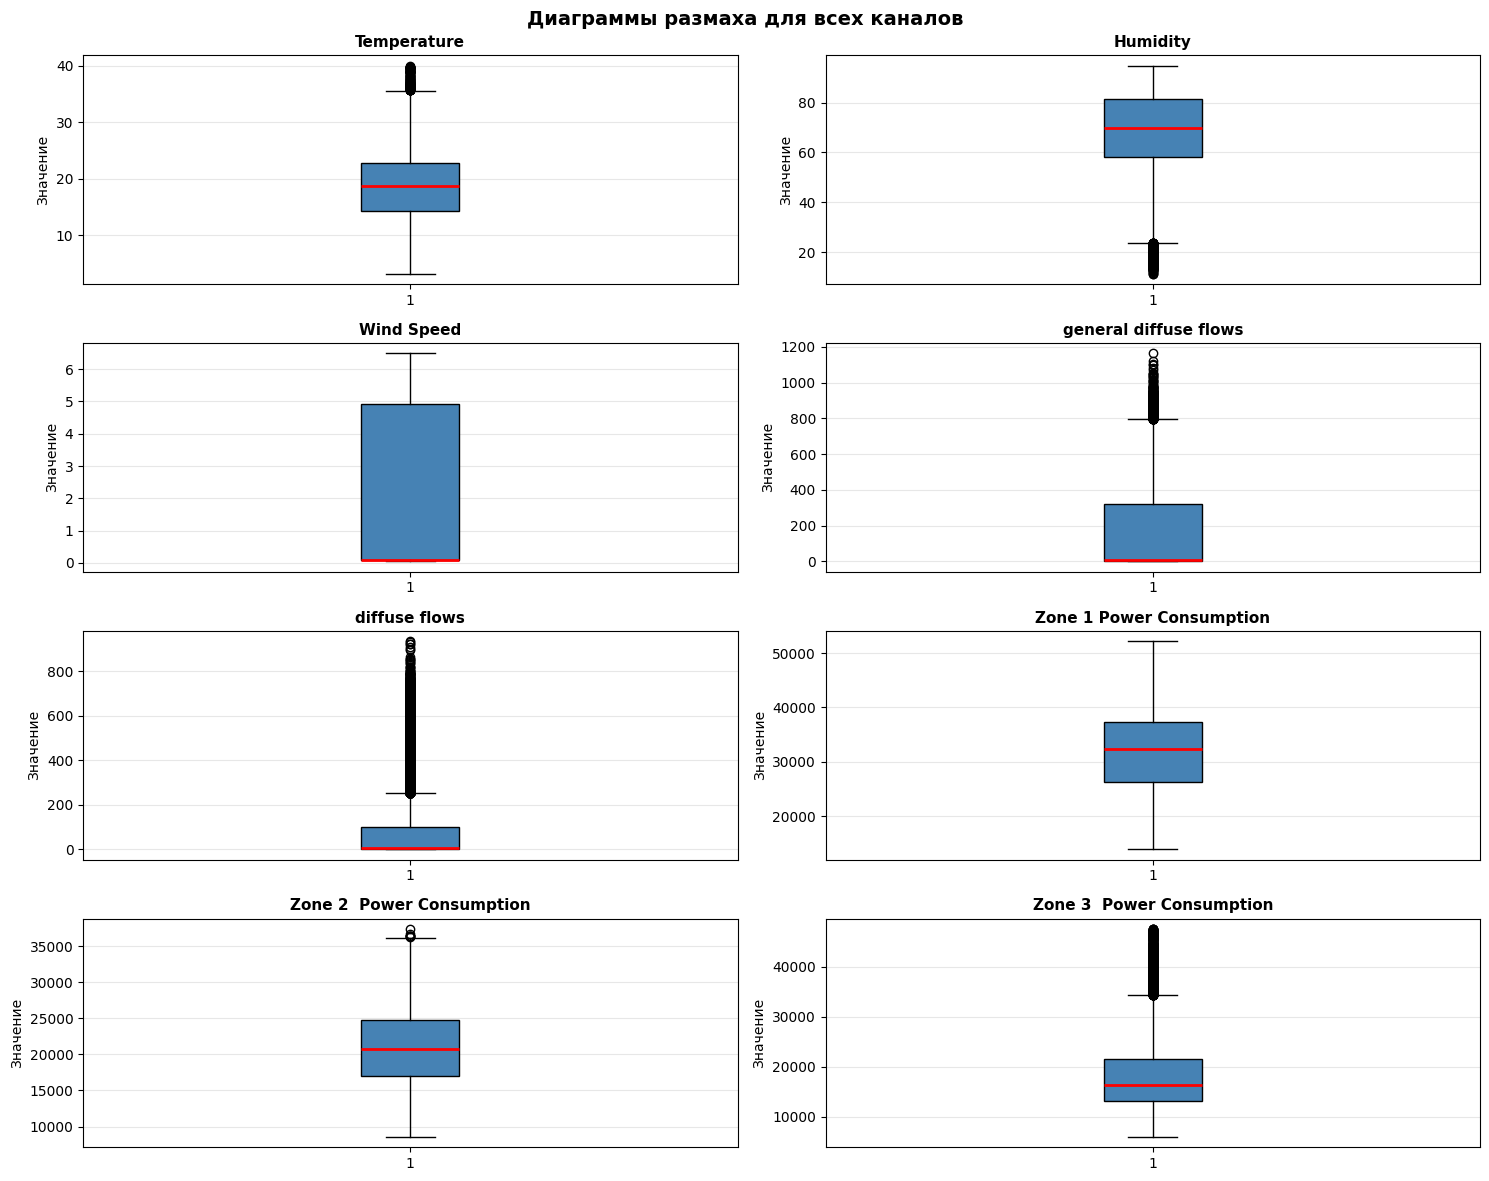

In [30]:
# Подсчет выбросов по правилу 3 сигм

def count_outliers_3sigma(data):
    mean = data.mean()
    std = data.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers), (len(outliers) / len(data)) * 100, lower_bound, upper_bound

print("Выбросы по правилу 3 сигм")

for channel in channels:
    count, percent, lower, upper = count_outliers_3sigma(df[channel])
    print(f"{channel:30} : {count:5} выбросов ({percent:.2f}%)")
    print(f"   Диапазон: [{lower:.2f}, {upper:.2f}]")

# Создание диаграммы размаха для всех каналов
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, channel in enumerate(channels):
    axes[i].boxplot(df[channel].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(channel, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Значение')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Диаграммы размаха для всех каналов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

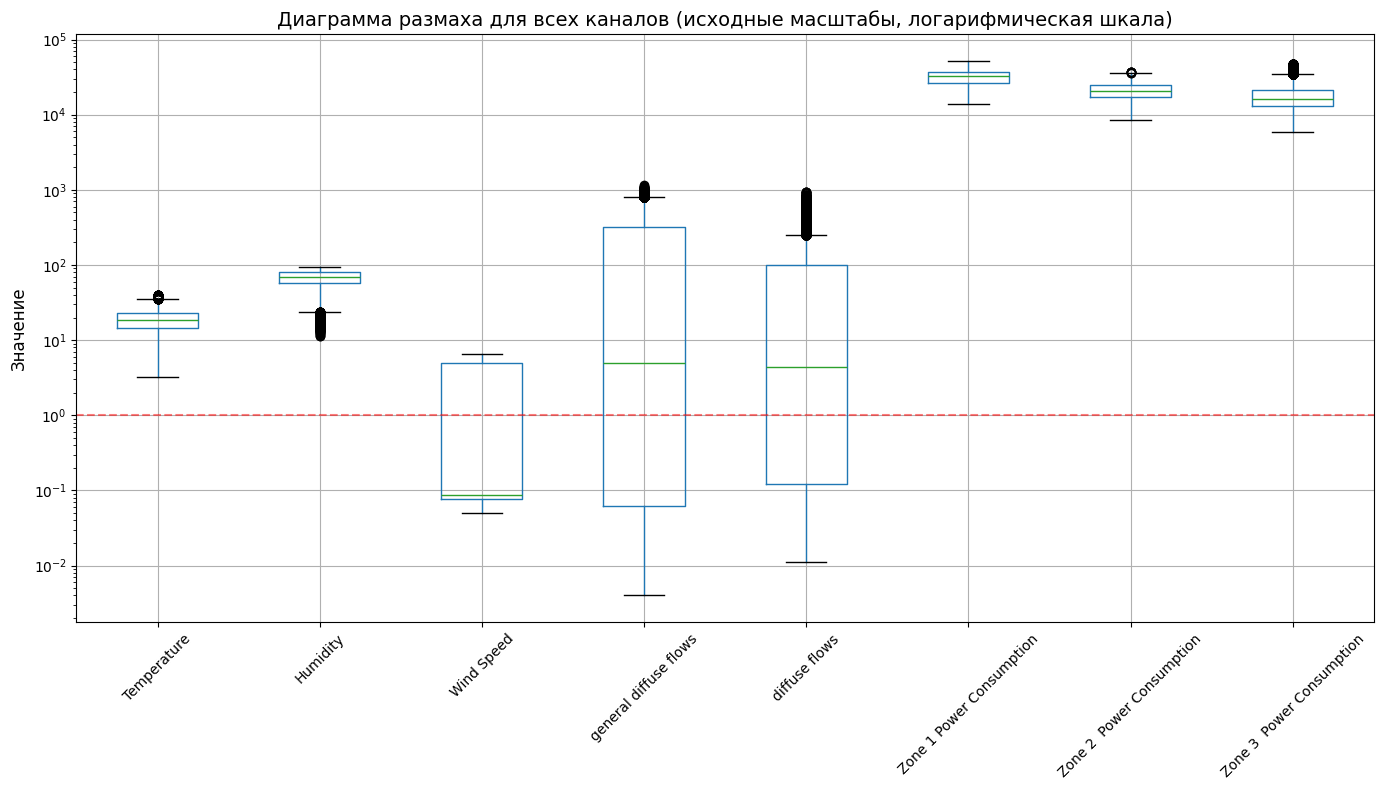

In [39]:
# Построение общей диаграммы размаха для всех каналов

# Создание DataFrame для boxplot (масштабирование для отображения)
df_box = df[channels].copy()

fig, ax = plt.subplots(figsize=(14, 8))

# Boxplot для исходных данных (логарифмическая шкала из-за разных масштабов)
df_box.boxplot(ax=ax, rot=45, grid=True)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title('Диаграмма размаха для всех каналов (исходные масштабы, логарифмическая шкала)', fontsize=14)
ax.set_yscale('log')
ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
# Вычисление матрицы корреляции
corr_matrix = df[channels].corr(method='pearson')

print("Матрица корреляции Пирсона")
print(corr_matrix.round(3))

Матрица корреляции Пирсона
                           Temperature  Humidity  Wind Speed  \
Temperature                       1.00     -0.46        0.48   
Humidity                         -0.46      1.00       -0.14   
Wind Speed                        0.48     -0.14        1.00   
general diffuse flows             0.46     -0.47        0.13   
diffuse flows                     0.20     -0.26       -0.00   
Zone 1 Power Consumption          0.44     -0.29        0.17   
Zone 2  Power Consumption         0.38     -0.29        0.15   
Zone 3  Power Consumption         0.49     -0.23        0.28   

                           general diffuse flows  diffuse flows  \
Temperature                                 0.46           0.20   
Humidity                                   -0.47          -0.26   
Wind Speed                                  0.13          -0.00   
general diffuse flows                       1.00           0.56   
diffuse flows                               0.56           1.

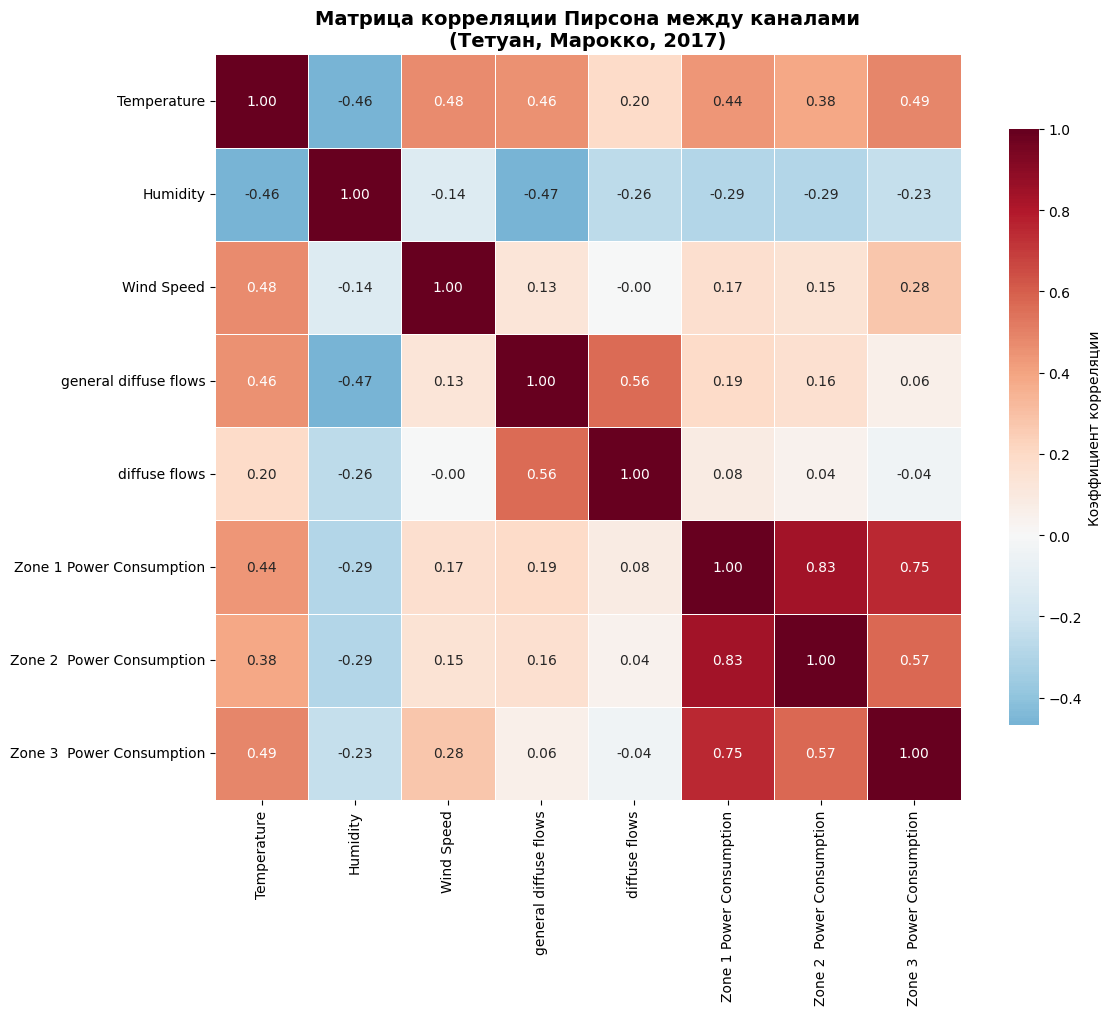

In [45]:
# Построение тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,           # показывать значения
            fmt='.2f',            # формат с 2 знаками
            cmap='RdBu_r',        # красно-синяя цветовая схема
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'})
plt.title('Матрица корреляции Пирсона между каналами\n(Тетуан, Марокко, 2017)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

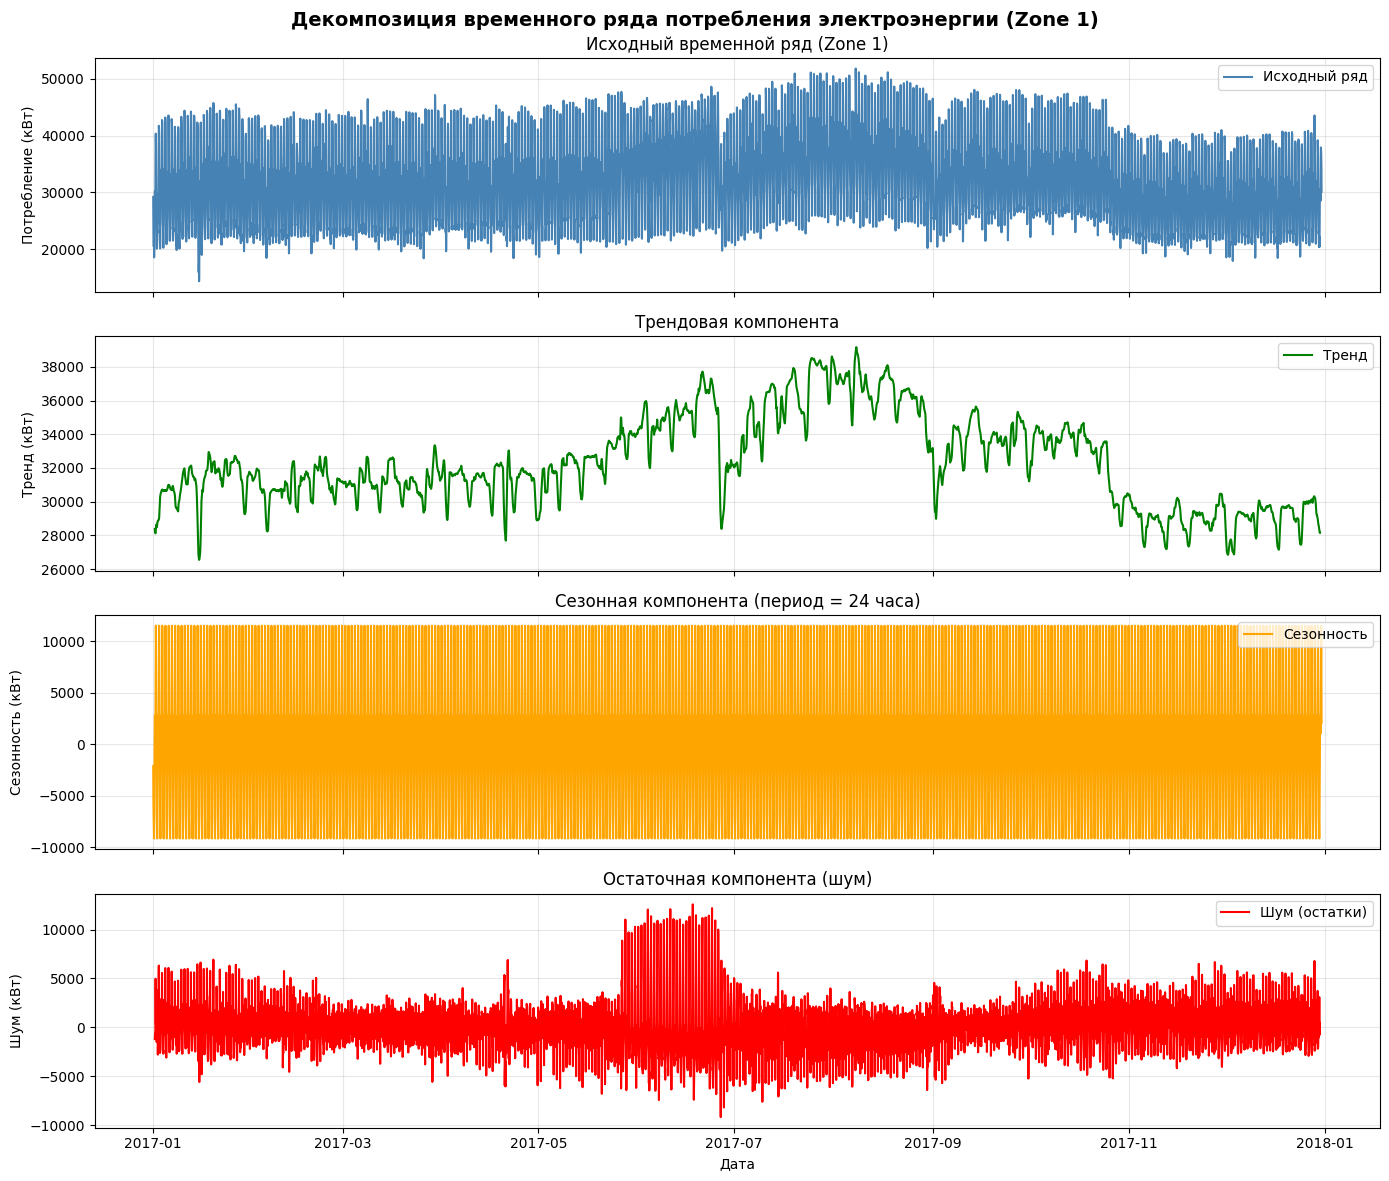

In [55]:
# Декомпозицию ряда на три
# составляющие (тренд, сезонная компонента, остатки (шум))

# Ключевой канал (Zone 1 Power Consumption)
# Агрегирование до часовых данных для декомпозиции (1440 минут = 24 часа * 60 минут)
# При шаге 10 минут: 6 измерений в час, 144 измерения в сутки

# Агрегирование до часовых данных (берем среднее за каждый час)
df_hourly = df.resample('h').mean()

# Выбор целевого канала
target = 'Zone 1 Power Consumption'
series = df_hourly[target].dropna()

# Период сезонности: 24 (суточная сезонность для часовых данных)
period = 24

# Выполнение декомпозиции (аддитивная модель)
decomposition = seasonal_decompose(series, model='additive', period=period)

# Извлечение компоненты
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Визуализация
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(series, label='Исходный ряд', color='steelblue')
axes[0].set_ylabel('Потребление (кВт)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Исходный временной ряд (Zone 1)', fontsize=12)

axes[1].plot(trend, label='Тренд', color='green')
axes[1].set_ylabel('Тренд (кВт)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Трендовая компонента', fontsize=12)

axes[2].plot(seasonal, label='Сезонность', color='orange')
axes[2].set_ylabel('Сезонность (кВт)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Сезонная компонента (период = 24 часа)', fontsize=12)

axes[3].plot(residual, label='Шум (остатки)', color='red')
axes[3].set_ylabel('Шум (кВт)')
axes[3].set_xlabel('Дата')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].set_title('Остаточная компонента (шум)', fontsize=12)

plt.suptitle('Декомпозиция временного ряда потребления электроэнергии (Zone 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

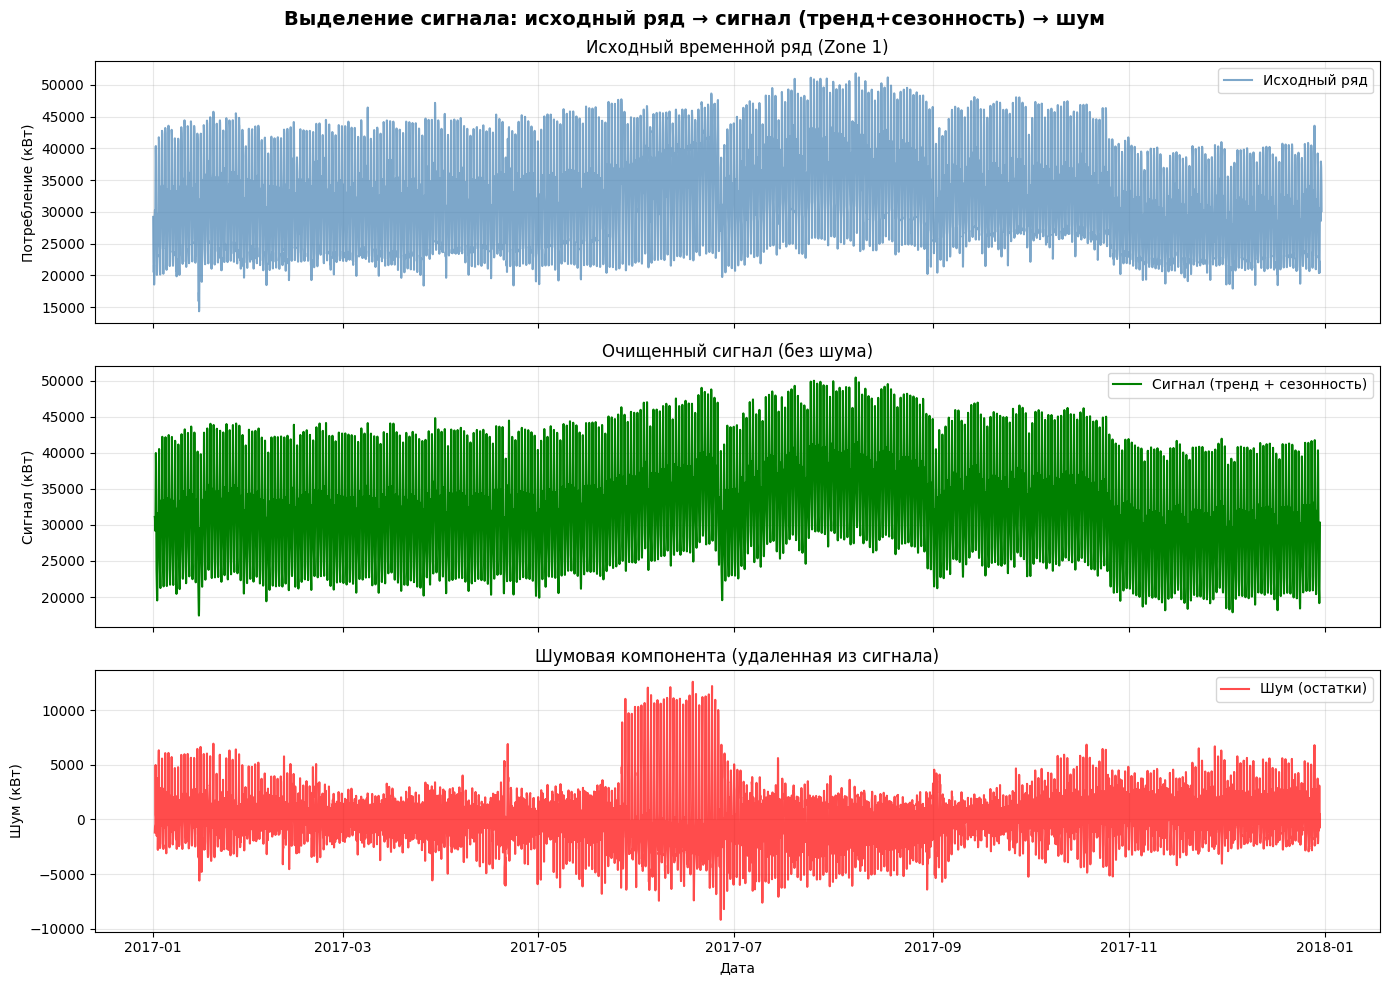

Анализ сигнала и шума
Дисперсия сигнала (тренд+сезонность): 44935249.13
Дисперсия шума (остатки): 4758777.28
Отношение сигнал/шум (SNR): 9.75 дБ


In [57]:
# Выделение сигнала, объединяя тренд и сезонную компоненту

# Для аддитивной модели (model='additive')
# Сигнал = тренд + сезонность

signal = trend + seasonal

# Удаление NaN значения (они появляются по краям из-за скользящих окон)
signal_clean = signal.dropna()

# Визуализация: сравнение исходного ряда, сигнала и шума
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Исходный ряд
axes[0].plot(series, label='Исходный ряд', color='steelblue', alpha=0.7)
axes[0].set_ylabel('Потребление (кВт)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Исходный временной ряд (Zone 1)', fontsize=12)

# Сигнал (тренд + сезонность)
axes[1].plot(signal_clean, label='Сигнал (тренд + сезонность)', color='green', linewidth=1.5)
axes[1].set_ylabel('Сигнал (кВт)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Очищенный сигнал (без шума)', fontsize=12)

# Шум (остатки)
axes[2].plot(residual, label='Шум (остатки)', color='red', alpha=0.7)
axes[2].set_ylabel('Шум (кВт)')
axes[2].set_xlabel('Дата')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Шумовая компонента (удаленная из сигнала)', fontsize=12)

plt.suptitle('Выделение сигнала: исходный ряд → сигнал (тренд+сезонность) → шум', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Анализ сигнала и шума")
print(f"Дисперсия сигнала (тренд+сезонность): {signal_clean.var():.2f}")
print(f"Дисперсия шума (остатки): {residual.dropna().var():.2f}")

# SNR
var_signal = signal_clean.var()
var_noise = residual.dropna().var()
SNR = 10 * np.log10(var_signal / var_noise)
print(f"Отношение сигнал/шум (SNR): {SNR:.2f} дБ")

In [59]:
# Вычисление сигнала (тренд + сезонность)

# Сигнал = тренд + сезонность (для аддитивной модели)
signal = trend + seasonal

# Удаление NaN значения (по краям ряда)
signal_clean = signal.dropna()
residual_clean = residual.dropna()

# Расчет дисперсий
var_signal = signal_clean.var()   # дисперсия сигнала
var_noise = residual_clean.var()  # дисперсия шума

# Расчет SNR
SNR = 10 * np.log10(var_signal / var_noise)

print("Расчет отношения сигнал/шум (SNR)")
print(f"Дисперсия сигнала (σ² сигнал): {var_signal:.2f}")
print(f"Дисперсия шума (σ² шум): {var_noise:.2f}")
print(f"Отношение σ² сигнал / σ² шум: {var_signal / var_noise:.2f}")
print(f"SNR = 10 * log10({var_signal / var_noise:.2f}) = {SNR:.2f} дБ")

Расчет отношения сигнал/шум (SNR)
Дисперсия сигнала (σ² сигнал): 44935249.13
Дисперсия шума (σ² шум): 4758777.28
Отношение σ² сигнал / σ² шум: 9.44
SNR = 10 * log10(9.44) = 9.75 дБ


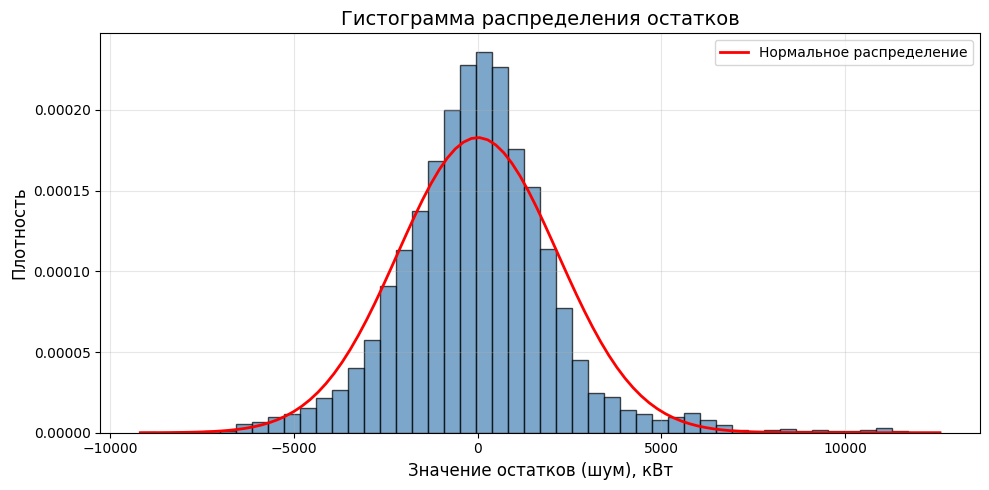

СТАТИСТИКА ШУМОВОЙ КОМПОНЕНТЫ
Среднее значение остатков: 0.640177 (должно быть близко к 0)
Стандартное отклонение: 2181.4622
Асимметрия (skewness): 0.6851
Эксцесс (kurtosis): 3.4444

Вывод: Распределение имеет отклонения от нормального.


In [62]:
# Потсроение гистограммы распределения остатков

# Остатки (шум) уже получены из декомпозиции
residual_clean = residual.dropna()

# Построение гистограммы
fig, ax = plt.subplots(figsize=(10, 5))

# Гистограмма с плотностью (чтобы сравнить с нормальным распределением)
ax.hist(residual_clean, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)

# Добавляем линию нормального распределения для сравнения
mu = residual_clean.mean()
sigma = residual_clean.std()
x = np.linspace(residual_clean.min(), residual_clean.max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Нормальное распределение')

# Настройки графика
ax.set_xlabel('Значение остатков (шум), кВт', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.set_title('Гистограмма распределения остатков', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("СТАТИСТИКА ШУМОВОЙ КОМПОНЕНТЫ")
print(f"Среднее значение остатков: {mu:.6f} (должно быть близко к 0)")
print(f"Стандартное отклонение: {sigma:.4f}")
print(f"Асимметрия (skewness): {residual_clean.skew():.4f}")
print(f"Эксцесс (kurtosis): {residual_clean.kurtosis():.4f}")

# Оценка нормальности
if abs(mu) < 0.01 and abs(residual_clean.skew()) < 0.5:
    print("\nВывод: Распределение близко к нормальному.")
else:
    print("\nВывод: Распределение имеет отклонения от нормального.")